In [3]:
# Run this inside of sf_curr to get the environment paths (for causal forcing)
# ! source get_paths.sh web sf_curr

In [4]:
import os
os.environ['DATASET_PATH'] = '/shared/john/model_training/'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

device = 'cuda:0'


In [ ]:
import torch
from omegaconf import OmegaConf
from pipeline import CausalInferencePipeline


# actual config not important as we just load model weights, this will default to original weights if not replaced, some values just need to be instantiated
config_path = "/home/john_zhou/research/arvd_repos/sf_curr/configs/self_forcing_dmd.yaml"
config = OmegaConf.load(config_path)
default_config = OmegaConf.load("configs/default_config.yaml")
config = OmegaConf.merge(default_config, config)

pipeline = CausalInferencePipeline(config, device=device) # just sending to cpu since I am not doing inference
pipeline = pipeline.to(device)

pipeline.vae.to('cpu')
pipeline.text_encoder.to('cpu')
torch.cuda.empty_cache()

using 1.3b model


KeyboardInterrupt: 

In [46]:
# load checkpoint weights from causal forcing
ar_model = torch.load("/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/causal_forcing/chunkwise/ar_diffusion.pt", map_location=device)
ode_model = torch.load("/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/causal_forcing/chunkwise/causal_ode.pt", map_location=device)
dmd_model = torch.load("/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/causal_forcing/chunkwise/causal_forcing.pt", map_location=device)

In [50]:
import tqdm
def get_diffs(model1, model2, is_model1_a_pipeline:bool = False ):
    # takes difference between model1 and model2. 
    # is_model1_a_pipeline allows the model to take a difference with the pipeline's generator

    if is_model1_a_pipeline:
        model1_names = set(['model.'+name for name, param in model1.generator.model.named_parameters()])
    else:
        model1_names = set([name for name, param in model1['generator'].items()])

    model2_names = set([name for name, param in model2['generator'].items()])

    # base_names = set([name for name, param in ode_model['generator'].items()])

    assert len(model1_names - model2_names) == 0 and len(model1_names.intersection(model2_names)) == len(model1_names), "model1 and model2 do not have the same # of parameters or the same parameter names"

    # get weight differences
    diffs = []
    if is_model1_a_pipeline:
        iteration_items = tqdm.tqdm(pipeline.generator.model.named_parameters()) 
    else:
        iteration_items = tqdm.tqdm(model1['generator'].items())

    for name, param in iteration_items:
        key = "model." + name if ("model." + name) in model2_names else name
        other = model2['generator'][key]

        diffs.append((param - other).reshape(-1))


    return torch.cat(diffs)



In [ ]:
# Obtain weight differences
diffs_dmd_base = get_diffs(pipeline, dmd_model, is_model1_a_pipeline=True)
diffs_ar_base = get_diffs(pipeline, ar_model, is_model1_a_pipeline=True)
diffs_ode_ar = get_diffs(ar_model, ode_model, is_model1_a_pipeline=False)
diffs_dmd_ode = get_diffs(ode_model, dmd_model, is_model1_a_pipeline=False)

825it [00:00, 15334.95it/s]


# Plot Weight Differences

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_value_distribution(
    diffs_tensor,
    bins=200,
    title=r"Distribution of elements",
    include_min_max=False,
    zoom_in=False,
    ax=None,
):
    vals = diffs_tensor.detach().float().cpu().reshape(-1).numpy()

    if zoom_in:
        bounds = [-(vals.mean() + 3 * vals.std()), vals.mean() + 3 * vals.std()]
    else:
        bounds = [vals.min(), vals.max()]

    # Create figure/axis only if one was not provided
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
        created_fig = True
    else:
        fig = ax.figure

    counts, bin_edges, patches = ax.hist(vals, bins=bins, range=(bounds[0], bounds[1]))

    if include_min_max:
        min_val = vals.min()
        max_val = vals.max()

        ax.axvline(min_val, color='red', linestyle='--', linewidth=1.5, label=f"Min: {min_val:.4f}")
        ax.axvline(max_val, color='green', linestyle='--', linewidth=1.5, label=f"Max: {max_val:.4f}")

    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # Only show legend if something was labeled
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend()

    fig.tight_layout()

    if created_fig:
        plt.show()

    return fig, ax


def plot_combined_value_distributions(
    diffs_tensor,
    bins=200,
    full_title=r"Full distribution of elements",
    zoom_title=r"Zoomed distribution of elements ($\pm 3\sigma$)",
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    plot_value_distribution(
        diffs_tensor,
        bins=bins,
        title=full_title,
        include_min_max=True,
        zoom_in=False,
        ax=axes[0],
    )

    plot_value_distribution(
        diffs_tensor,
        bins=bins,
        title=zoom_title,
        include_min_max=False,
        zoom_in=True,
        ax=axes[1],
    )

    fig.tight_layout()
    plt.show()
    return fig, axes


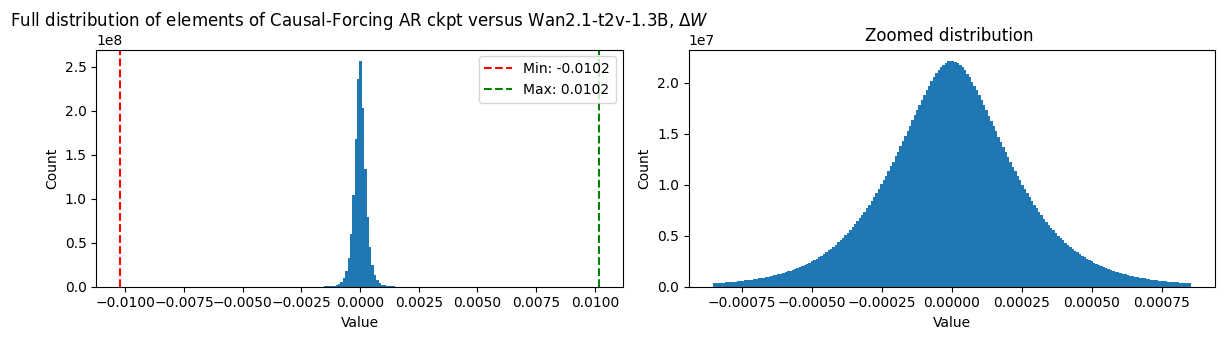

(<Figure size 1200x350 with 2 Axes>,
 array([<Axes: title={'center': 'Full distribution of elements of Causal-Forcing AR ckpt versus Wan2.1-t2v-1.3B, $\\Delta W$'}, xlabel='Value', ylabel='Count'>,
        <Axes: title={'center': 'Zoomed distribution '}, xlabel='Value', ylabel='Count'>],
       dtype=object))

In [ ]:
plot_combined_value_distributions(
    diffs_ar_base,
    bins=200,
    full_title=r"Full distribution of elements of Causal-Forcing AR ckpt versus Wan2.1-t2v-1.3B, $\Delta W$",
    zoom_title=r"Zoomed distribution",
)

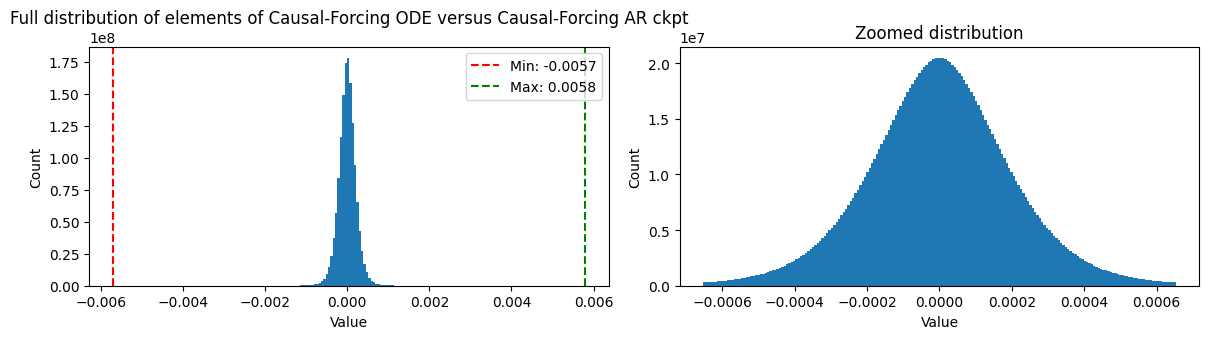

(<Figure size 1200x350 with 2 Axes>,
 array([<Axes: title={'center': 'Full distribution of elements of Causal-Forcing ODE versus Causal-Forcing AR ckpt'}, xlabel='Value', ylabel='Count'>,
        <Axes: title={'center': 'Zoomed distribution'}, xlabel='Value', ylabel='Count'>],
       dtype=object))

In [55]:
plot_combined_value_distributions(
    diffs_ode_ar,
    bins=200,
    full_title=r"Full distribution of elements of Causal-Forcing ODE versus Causal-Forcing AR ckpt",
    zoom_title=r"Zoomed distribution",
)

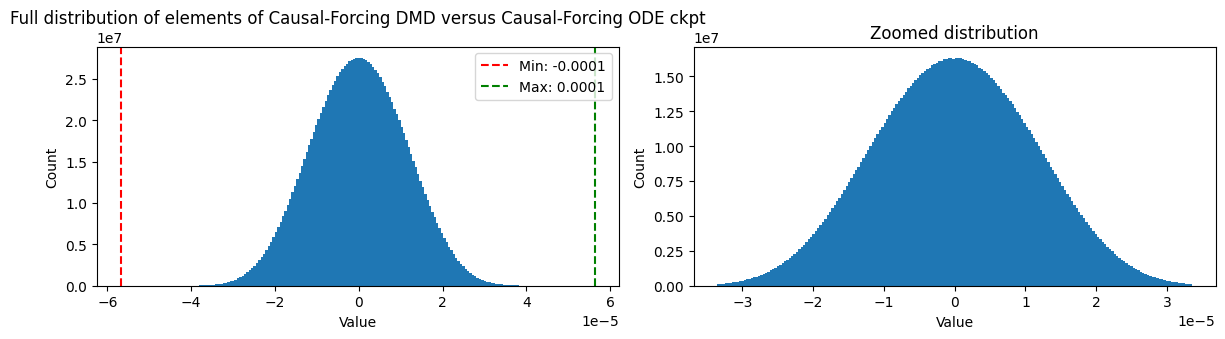

(<Figure size 1200x350 with 2 Axes>,
 array([<Axes: title={'center': 'Full distribution of elements of Causal-Forcing DMD versus Causal-Forcing ODE ckpt'}, xlabel='Value', ylabel='Count'>,
        <Axes: title={'center': 'Zoomed distribution'}, xlabel='Value', ylabel='Count'>],
       dtype=object))

In [56]:
plot_combined_value_distributions(
    diffs_dmd_ode,
    bins=200,
    full_title=r"Full distribution of elements of Causal-Forcing DMD versus Causal-Forcing ODE ckpt",
    zoom_title=r"Zoomed distribution",
)

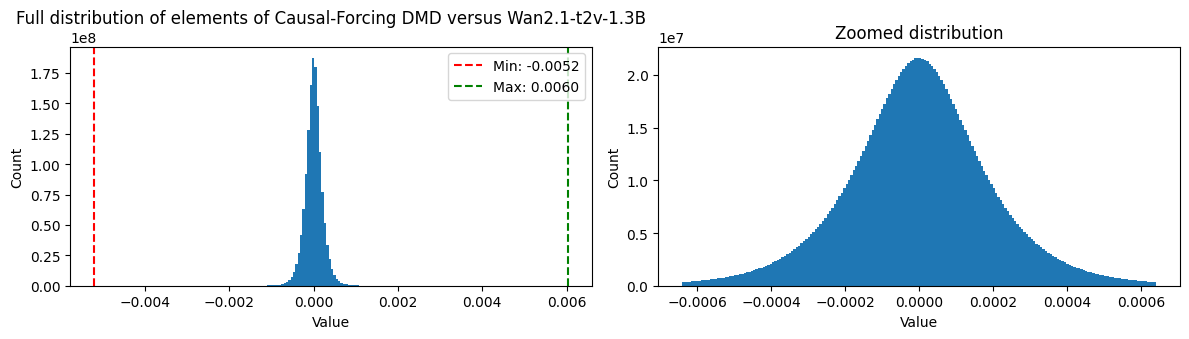

(<Figure size 1200x350 with 2 Axes>,
 array([<Axes: title={'center': 'Full distribution of elements of Causal-Forcing DMD versus Wan2.1-t2v-1.3B'}, xlabel='Value', ylabel='Count'>,
        <Axes: title={'center': 'Zoomed distribution'}, xlabel='Value', ylabel='Count'>],
       dtype=object))

In [64]:
plot_combined_value_distributions(
    diffs_dmd_base,
    bins=200,
    full_title=r"Full distribution of elements of Causal-Forcing DMD versus Wan2.1-t2v-1.3B",
    zoom_title=r"Zoomed distribution",
)